In [ ]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [ ]:
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target=[1]*35+[0]*14

In [ ]:
print(fish_data) #입력데이터
print(fish_target) #정답

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

In [ ]:
print(fish_data[4])

In [ ]:
train_input = fish_data[:35] #훈련데이터
train_target = fish_target[:35]

test_input = fish_data[35:] #평가데이터
test_target = fish_target[35:]

In [ ]:
kn.fit(train_input, train_target) #훈련
kn.score(test_input, test_target) #평가

정확도 0 -> why? 훈련데이터에는 도미만, 평가데이터에는 빙어만 있기 때문


In [ ]:
import numpy as np

input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

In [ ]:
np.random.seed(42)
index = np.arange(49)
np.random.shuffle(index) #랜덤으로 섞어줌

In [ ]:
print(index)

In [ ]:
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

In [ ]:
test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(test_input[:,0], test_input[:,1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

도미와 빙어가 파란색(훈련데이터)와 주황색(평가데이터)로 골고루 섞임

In [ ]:
kn.fit(train_input, train_target)
kn.score(test_input, test_target) #다시 훈련

사이킷런 라이브러리를 사용해 훈련데이터와 평가데이터를 나눔

길이특성과 무게특성을 묶어 2차원 배열

In [ ]:
fish_data = np.column_stack((fish_length,fish_weight))
print(fish_data[:5])

In [ ]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [ ]:
print(fish_target)

In [ ]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42)

입력과 타킷을 train_test_split() 함수에 파라미터로 넣어 25%는 평가데이터, 나머지는 훈련데이터로 분리

In [ ]:
print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)
#36개와 12개로 나눔, 2차원배열이라는 뜻

In [ ]:
print(test_target)

원래 도미와 빙어의 비율은 약 2.5:1

이 평가데이터의 비율은 약 3.3:1 -> 비율을 맞추자 ! (stratify)

In [ ]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)

In [ ]:
print(test_target)

K-최근접 이웃 알고리즘을 사용해 머신러닝 모델을 평가

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target) #다시 훈련

In [ ]:
print(kn.predict([[25, 150]]))

빙어로 분류 -> why? 가까운 샘플 5개와 같은 타깃으로 예측

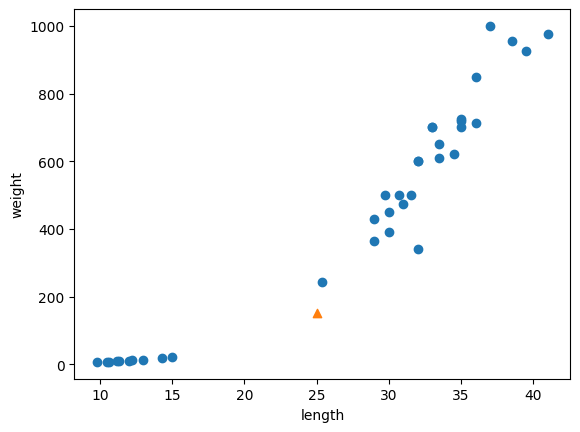

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
distances, indexes = kn.kneighbors([[25, 150]])
# 이웃 5개까지의 거리와 인덱스를 담은 배열

In [ ]:
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
print(train_input[indexes])
print(train_target[indexes])
print(distances)

가장 가까운 점은 거리가 92, 가장 먼 점은 거리가 138

-> 그래프로 보면 거리 비율이 이상

x축 범위와 y축 범위가 다르기 때문 -> 스케일을 동일하게 맞춰야 함

# 데이터 전처리
표준점수 = ( 데이터값 - 평균 ) / 표준편차

In [ ]:
mean=np.mean(train_input, axis=0)
std=np.std(train_input, axis=0)

In [ ]:
print(mean, std)

In [ ]:
train_scaled = (train_input - mean) / std

In [ ]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

주황색 : 새로운 샘플 - 표준점수로 변환하지 않음

새로운 샘플들도 표준점수로 변환

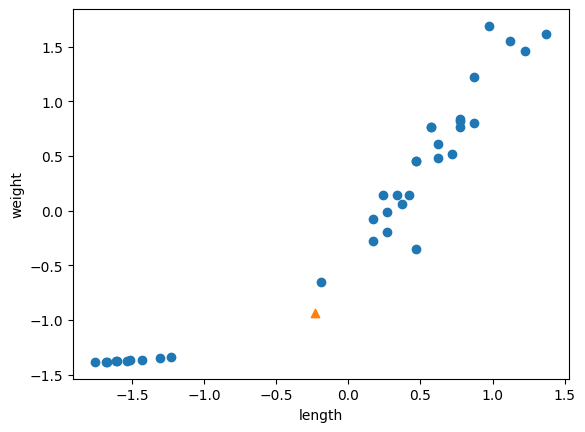

In [ ]:
new=([25,150]-mean)/std
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
kn.fit(train_scaled,train_target) #다시훈련

In [ ]:
test_scaled=(test_input-mean)/std

In [ ]:
kn.score(test_scaled, test_target)

In [ ]:
print(kn.predict([new]))

도미로 예측

In [ ]:
distances,indexes=kn.kneighbors([new])
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(new[0],new[1],marker='^')
plt.scatter(train_scaled[indexes,0],train_scaled[indexes,1],marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

k-최근접 이웃 알고리즘 다시 돌려본 결과 가까운 5개의 이웃을 도미로 찾아냄

# 과제
전체 훈련 데이터는 실습에서 사용한 데이터를 그대로 사용해주세요

먼저 전체 훈련 데이터를 훈련세트와 테스트 세트로 분리를 해볼겁니다

실습에서도 분리를 해보았지만 이번에는 우리가 원하는 비율로 분리를 해보겠습니다

Q1. test_size 파라미터를 사용해 7:3으로 데이터를 분리해봐요

Q2. 5:5로 분리해봐요

Q3. 9:1로 분리해봐요

Q4. 위의 1, 2, 3번의 결과로 분리가 잘되었는지 훈련 세트와 테스트 세트를 구성하는 샘플의 개수를 출력해봐요

ex)

[7:3 비율] 훈련 세트: ?개, 테스트 세트: ?개

[5:5 비율] 훈련 세트: ?개, 테스트 세트: ?개

[9:1 비율] 훈련 세트: ?개, 테스트 세트: ?개


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# 데이터 합치기 (작성하신 코드)
import numpy as np
fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [ ]:
# Q1. test_size 파라미터를 사용해 7:3으로 데이터를 분리해봐요
train_input_7, test_input_7, train_target_7, test_target_7 = train_test_split(fish_data, fish_target, test_size=0.3, random_state=42)


In [ ]:
# 7:3 분리 결과 확인
print(len(train_input_7), len(test_input_7))
print(len(train_target_7), len(test_target_7))

In [ ]:
# Q2. 5:5로 분리해봐요
train_input_5, test_input_5, train_target_5, test_target_5 = train_test_split(fish_data, fish_target, test_size=0.5, random_state=42)

In [ ]:
# 5:5 분리 결과 확인
print(len(train_input_5), len(test_input_5))
print(len(train_target_5), len(test_target_5))

In [ ]:
# Q3. 9:1로 분리해봐요
train_input_9, test_input_9, train_target_9, test_target_9 = train_test_split(fish_data, fish_target, test_size=0.1, random_state=42)

In [ ]:
# 9:1 분리 결과 확인
print(len(train_input_9), len(test_input_9))
print(len(train_target_9), len(test_target_9))

In [ ]:
# Q4. 위의 1, 2, 3번의 분리 결과로 KNN 알고리즘의 정확도를 테스트 해봐요
kn = KNeighborsClassifier()

In [ ]:
kn.fit(train_input_7, train_target_7)
kn.score(test_input_7, test_target_7)

In [ ]:
kn.fit(train_input_5, train_target_5)
kn.score(test_input_5, test_target_5)

In [ ]:
kn.fit(train_input_9, train_target_9)
kn.score(test_input_9, test_target_9)

전부 100%

앞에서 여러 비율로 테스트 세트와 훈련세트를 분리하고 KNN 알고리즘의 정확도를 테스트 해봤는데요

그중에서 7:3 비율로 나눈 훈련세트와 테스트 세트를 사용하겠습니다

훈련세트와 테스트 세트를 분리했으니 이제 축의 스케일을 맞춰줘야합니다

실습에서는 numpy 라이브러리를 사용해서 평균과 표준편차를 구했는데

이번에는 nupmy 라이브러리를 사용하지 않고 직접 평균과 표준편차를 구해보겠습니다

# 과제: Numpy 없이 순수 파이썬으로 표준점수 스케일링하기


In [ ]:
lengths = [fish[0] for fish in train_input]
weights = [fish[1] for fish in train_input]
n = len(train_input)
print(n)

In [ ]:
# Q1. sum() 함수를 이용해 길이와 무게의 평균을 구하세요.
mean_length = sum(lengths) / n
mean_weight = sum(weights) / n

In [ ]:
# Q2. for문과 ** 연산자를 이용해 길이와 무게의 분산을 구하세요.
# 힌트: 분산 = (각 데이터 - 평균)의 제곱의 합 / 데이터 개수
var_length = 0

for i in lengths:
  var_length += (i - mean_length) ** 2
var_length = var_length / n

var_weight = 0

for i in weights:
  var_weight += (i - mean_weight) ** 2
var_weight = var_weight / n

In [ ]:
# Q3. 분산에 제곱근을 씌워 표준편차를 구하세요. ( ** 0.5 이용 )
std_length = var_length ** 0.5
std_weight = var_weight ** 0.5

In [ ]:
# Q4. 구해진 평균과 표준편차를 이용해 train_input의 모든 데이터를 스케일링하여 새로운 리스트에 담으세요.
train_scaled_manual = []

for fish in train_input:
  scaled_length = (fish[0] - mean_length) / std_length
  scaled_weight = (fish[1] - mean_weight) / std_weight

  train_scaled_manual.append([scaled_length, scaled_weight])


In [ ]:
# 확인용 평균과 표준편차 출력
print(f"수동 계산 평균: {mean_length:.2f}, {mean_weight:.2f}")
print(f"수동 계산 표준편차: {std_length:.2f}, {std_weight:.2f}")
print(f"스케일링된 첫 데이터: {train_scaled_manual[0]}")

수동 계산 평균: 27.30, 454.10
수동 계산 표준편차: 9.98, 323.30
스케일링된 첫 데이터: [np.float64(0.2407003866560286), np.float64(0.1419824570898689)]


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# 1. 스케일링된 2차원 리스트에서 길이(X축)와 무게(Y축) 데이터 분리하기
scaled_lengths = [fish[0] for fish in train_scaled_manual]
scaled_weights = [fish[1] for fish in train_scaled_manual]

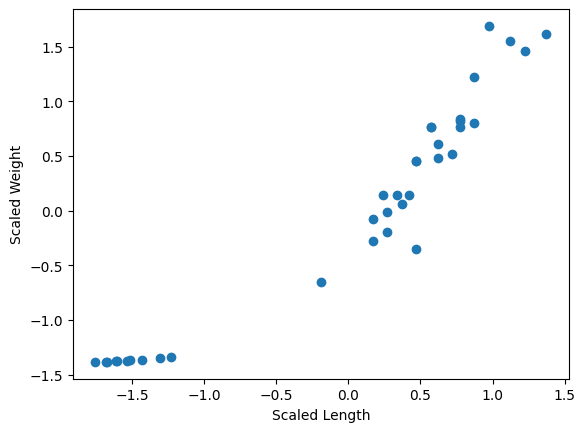

In [ ]:
plt.scatter(scaled_lengths, scaled_weights)

plt.xlabel("Scaled Length")
plt.ylabel("Scaled Weight")

plt.show()